# Testing the per round error rate for Tesseract and relay BP: Arianna Wrappers

In [1]:
# get the parity check matrix / logicals for the BB codes
from realtime_decoding.decoder_switching import get_BB_circuit
from quits.qldpc_code import BbCode
from quits import ErrorModel

def get_bb_code_parity_and_logs(d):

    d_dict = {6:{'l':6, 'm':6, 'A_x_pows': [3], 'A_y_pows': [1,2], 'B_x_pows': [1,2], 'B_y_pows':[3]},
                10: {'l':15, 'm':3, 'A_x_pows': [9], 'A_y_pows': [1,2], 'B_x_pows': [2,7], 'B_y_pows':[0]},
                12:{'l':12, 'm':6, 'A_x_pows': [3], 'A_y_pows': [1,2], 'B_x_pows': [1,2], 'B_y_pows':[3]},}
    code_params = d_dict[d]
    bb = BbCode(
        l=code_params['l'],
        m=code_params['m'],
        A_x_pows=code_params['A_x_pows'],
        A_y_pows=code_params['A_y_pows'],
        B_x_pows=code_params['B_x_pows'],
        B_y_pows=code_params['B_y_pows'],
    )
    return bb.hx, bb.lx

In [2]:
# get UF thresholds... then add them to the plot
from realtime_decoding.decoder_switching import get_BB_circuit, get_rsc_circuits
from realtime_decoding.decoding import UnionFindWrapper, TesseractWrapper, RelayBpWrapper  
from quits import sliding_window_circuit_mem
from filelock import FileLock
import numpy as np
import pandas as pd
import psutil
import os


# decoder_params = {"window_observables":[],
#                 #   "priors":[],
#                   'det_beam': 10,
#                   'pqlimit': 50_000,
#                   'beam_climbing': True,
#                   'no_revisit_dets': True}

decoder_params =  {
        'gamma_dist_interval': (-0.175, 0.575),
        'gamma0': 0.125,
        'pre_iter': 80,
        'num_sets': 300,
        'set_max_iter': 60,
        'stop_nconv' : 1 }

def get_memory_usage():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 * 1024)  # Return in MB


def run_single_trial(p, d, code_type, num_shots, rounds,basis, csv_filename):
    task_id = f"p={p:.4f}, d={d}"
    print(f"[{task_id}] Starting trial. Memory: {get_memory_usage():.2f} MB")
    nbuffer = d            #W-F = buffer -> W = buffer +F
    F       = d//2         #just pick this commit region so that there are at least some windows to decode for rds>20 (e.g. for d=12, we have 20 rounds, and W = 12 +6 = 18)
    W       = nbuffer + F  #entire window

    # 1. Circuit Generation
    if code_type == "RSC":
        rsc_circuits, rsc_codes = get_rsc_circuits(p, [d], basis)
        circuit, code_params = rsc_circuits[0], rsc_codes[0]
    else:
        bb_circuit, bb_code = get_BB_circuit(d, basis, p, rounds)
        circuit = bb_circuit
        code_params = (bb_code.hx, bb_code.lx) if basis == 'x' else (bb_code.hz, bb_code.lz)

    sampler = circuit.compile_detector_sampler()
    det_events, obs_flips = sampler.sample(shots=num_shots, separate_observables=True)

    # 2. Decoding using TesseractWrapper
    logical_pred = sliding_window_circuit_mem(
        det_events, circuit, code_params[0], code_params[1],
        W, F, 
        RelayBpWrapper, RelayBpWrapper, 
        decoder_params, decoder_params,
        'priors', 'priors', 'decode', 'decode'
    )    
    pL = np.mean((obs_flips - logical_pred).any(axis=1))
    eps = 1-(1-pL)**(1/rounds)

    # 3. Log Preparation
    row = {
        'cutoff':0.0,'p': p, 'd': d, 'basis': basis,
        'num_shots': num_shots, 'code_type': code_type, 'cluster_metric':"size",
        'rounds': rounds, 'eps': eps
    }
    
    lock_path = csv_filename + ".lock"
    with FileLock(lock_path):
        df_row = pd.DataFrame([row])
        header_needed = not os.path.exists(csv_filename)
        df_row.to_csv(csv_filename, mode='a', index=False, header=header_needed)
    print(f"Logged results to {csv_filename}: {row}")
    print(f"[{task_id}] Finished trial. Memory: {get_memory_usage():.2f} MB")
    return row



In [9]:
from joblib import Parallel, delayed


p_list = [4e-3, 5e-3]
d_list = [6, 10, 12]
num_shots = 10_000
code_type = "BB"
rounds = 22
csv_file = "/Users/ariannameinking/Documents/Brown_Research/realtime_decoding_qldpc/data/raw/tesseract_characterization.csv"

tasks = [
    (p, d, code_type, num_shots, rounds, 'x', csv_file)
    for p in p_list 
    for d in d_list 
]

# 4. Parallel Execution
print(f"Starting {len(tasks)} parallel tasks...")
results = Parallel(n_jobs=-1, backend="loky")(
    delayed(run_single_trial)(*task) for task in tasks
)

print("All simulation tasks completed.")

Starting 6 parallel tasks...
[p=0.0040, d=6] Starting trial. Memory: 213.02 MB
[p=0.0040, d=12] Starting trial. Memory: 213.28 MB
[p=0.0050, d=6] Starting trial. Memory: 213.42 MB
[p=0.0040, d=10] Starting trial. Memory: 212.98 MB
[p=0.0050, d=10] Starting trial. Memory: 213.36 MB
[p=0.0050, d=12] Starting trial. Memory: 213.69 MB
Logged results to /Users/ariannameinking/Documents/Brown_Research/realtime_decoding_qldpc/data/raw/tesseract_characterization.csv: {'cutoff': 0.0, 'p': 0.004, 'd': 6, 'basis': 'x', 'num_shots': 10000, 'code_type': 'BB', 'cluster_metric': 'size', 'rounds': 22, 'eps': np.float64(0.002262014824609415)}
[p=0.0040, d=6] Finished trial. Memory: 244.25 MB
Logged results to /Users/ariannameinking/Documents/Brown_Research/realtime_decoding_qldpc/data/raw/tesseract_characterization.csv: {'cutoff': 0.0, 'p': 0.005, 'd': 6, 'basis': 'x', 'num_shots': 10000, 'code_type': 'BB', 'cluster_metric': 'size', 'rounds': 22, 'eps': np.float64(0.005583675763355722)}
[p=0.0050, d=6]

<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
/var/folders/m6/1pcn_m250l175cmxwtstjnxh0000gn/T/ipykernel_31698/3823796199.py:16: SyntaxWarning: invalid escape sequence '\e'
  ax.set_ylabel('$\epsilon$')


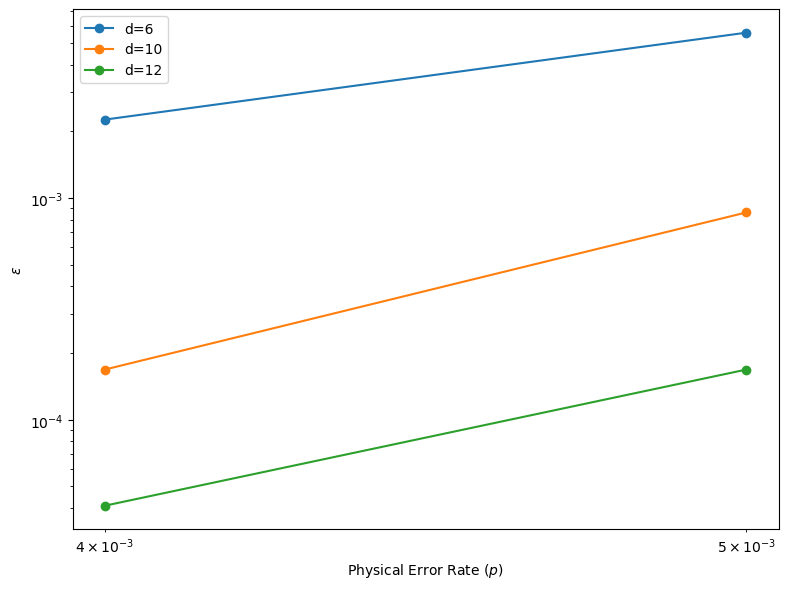

In [12]:
import matplotlib.pyplot as plt
df = pd.read_csv(csv_file)


fig, ax = plt.subplots(figsize=(8, 6))

# p_list = df['p'].unique()

d_list = df['d'].unique()
for d in d_list:
    df_d = df[(df['d'] == d) & (df['p'].isin(p_list))]
    ax.plot(p_list, df_d['eps'], marker='o', label=f'd={d}')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Physical Error Rate ($p$)')
ax.set_ylabel('$\epsilon$')
ax.legend()
plt.tight_layout()
plt.show()

### Get BB Code threshold comparison for different decoder

In [ ]:
# Relay BP


# get UF thresholds... then add them to the plot
from realtime_decoding.decoder_switching_class import *
from quits import sliding_window_circuit_mem
from filelock import FileLock
import numpy as np
import pandas as pd
import psutil
import os


decoder_params =  {
        'gamma_dist_interval': (-0.175, 0.575),
        'gamma0': 0.125,
        'pre_iter': 80,
        'num_sets': 300,
        'set_max_iter': 60,
        'stop_nconv' : 1 }

def get_memory_usage():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 * 1024)  # Return in MB


def run_single_trial(p, d, code_name, num_shots, rounds,basis, csv_filename):
    task_id = f"p={p:.4f}, d={d}"
    print(f"[{task_id}] Starting trial. Memory: {get_memory_usage():.2f} MB")
    nbuffer = d            #W-F = buffer -> W = buffer +F
    F       = d//2         #just pick this commit region so that there are at least some windows to decode for rds>20 (e.g. for d=12, we have 20 rounds, and W = 12 +6 = 18)
    W       = nbuffer + F  #entire window

    n, k, d = map(int, code_name.strip("[]").split(","))
    nbuffer = d            #W-F = buffer -> W = buffer +F
    F       = d//2         #just pick this commit region so that there are at least some windows to decode for rds>20 (e.g. for d=12, we have 20 rounds, and W = 12 +6 = 18)
    W       = nbuffer + F  #entire window
    num_rounds = 20

    test  = decoder_switching_class(code_name=code_name,
                                    num_rounds=num_rounds,
                                    p=p,
                                    basis=basis,
                                    num_shots=num_shots,
                                    W=W,
                                    F=F,
                                    strong_decoder_option=strong_decoder,
                                    weak_decoder_option=weak_decoder,) 
    shots, cluster_norms_per_shot, result = test.decode_with_sliding_window(decoder_option='weak', norm_order=np.inf, rel_error_tol=0.01) # cluster norm is over shots and windows - so just one for each shot
    cluster_dict[(p,d)] = cluster_norms_per_shot
    pL = np.mean((obs_flips - logical_pred).any(axis=1))
    eps = 1-(1-pL)**(1/rounds)

    # 3. Log Preparation
    row = {
        'cutoff':0.0,'p': p, 'd': d, 'basis': basis,
        'num_shots': num_shots, 'code_type': code_type, 'cluster_metric':"size",
        'rounds': rounds, 'eps': eps
    }
    
    lock_path = csv_filename + ".lock"
    with FileLock(lock_path):
        df_row = pd.DataFrame([row])
        header_needed = not os.path.exists(csv_filename)
        df_row.to_csv(csv_filename, mode='a', index=False, header=header_needed)
    print(f"Logged results to {csv_filename}: {row}")
    print(f"[{task_id}] Finished trial. Memory: {get_memory_usage():.2f} MB")
    return row




In [2]:
bb_codes_dict = { "[[98,6,12]]": {'l': 7, 'm': 7, 'A_x_pows': [3], 'A_y_pows': [5,6], 'B_x_pows': [3,5], 'B_y_pows': [2]}, 
                
                # https://arxiv.org/pdf/2408.10001 some codes taken from this paper (all CSS).
                 "[[54,8,6]]":    {'l': 3, 'm': 9, 'A_x_pows': [0], 'A_y_pows': [2,4], 'B_x_pows': [1,2], 'B_y_pows': [3]},      
                 "[[90,8,10]]": {'l':15, 'm':3, 'A_x_pows': [9], 'A_y_pows': [1,2], 'B_x_pows': [2,7], 'B_y_pows':[0]},      
                 "[[126,8,10]]":  {'l': 3, 'm': 21, 'A_x_pows': [0], 'A_y_pows': [2,10], 'B_x_pows': [1,2], 'B_y_pows': [3]}, 
                 "[[162,8,14]]":  {'l': 3, 'm': 27, 'A_x_pows': [0], 'A_y_pows': [10,14], 'B_x_pows': [1,2], 'B_y_pows': [12]}, 
                 "[[180,8,16]]": {'l': 6, 'm': 15, 'A_x_pows': [3], 'A_y_pows': [1,2], 'B_x_pows': [4,5], 'B_y_pows': [6]},    
                 
                 "[[150,16,8]]": {'l': 5, 'm': 15, 'A_x_pows': [0], 'A_y_pows': [6,8], 'B_x_pows': [1,4], 'B_y_pows': [5]}, 

                 "[[72,12,6]]":   {'l':6, 'm':6, 'A_x_pows': [3], 'A_y_pows': [1,2], 'B_x_pows': [1,2], 'B_y_pows':[3]},    
                 "[[144,12,12]]": {'l':12, 'm':6, 'A_x_pows': [3], 'A_y_pows': [1,2], 'B_x_pows': [1,2], 'B_y_pows':[3]},  
                 "[[288,12,18]]": {'l':12, 'm':12, 'A_x_pows': [3], 'A_y_pows': [2,7], 'B_x_pows': [1,2], 'B_y_pows':[3]},  
                 "[[360,12,24]]": {'l':30, 'm':6, 'A_x_pows': [9], 'A_y_pows': [1,2], 'B_x_pows': [25,26], 'B_y_pows':[3]},  

                 "[[288,24,12]]": {'l':12, 'm':12, 'A_x_pows': [6], 'A_y_pows': [1,2], 'B_x_pows': [2,4], 'B_y_pows':[3]},
                 "[[784,24,24]]": {'l':28, 'm':14, 'A_x_pows': [26], 'A_y_pows': [6,8], 'B_x_pows': [9,20], 'B_y_pows':[7]} 
                }

bb_codes_dict['[[90,8,10]]']

{'l': 15,
 'm': 3,
 'A_x_pows': [9],
 'A_y_pows': [1, 2],
 'B_x_pows': [2, 7],
 'B_y_pows': [0]}

In [2]:
from realtime_decoding.decoder_switching_class import *
num_rounds = 25
code_name = "[[72,12,6]]"
basis='Z' 

strong_decoder = 'relay_bp'
weak_decoder = 'bplsd' 
p      = 9e-3               #---> Should get ~6e-3 ler for p=6e-3 for bplsd.
cutoff = 5e-2

num_shots = 100
epsilon   = 0.2

n, k, d = map(int, code_name.strip("[]").split(","))

nbuffer = d            #Buffer region
F       = d//2         #Commit region
W       = nbuffer + F  #Entire window

test  = decoder_switching_class(code_name=code_name,
                                    num_rounds=num_rounds,
                                    p=p,
                                    basis=basis,
                                    num_shots=num_shots,
                                    W=W,
                                    F=F,
                                    strong_decoder_option=strong_decoder,
                                    weak_decoder_option=weak_decoder)    

new_shots,cluster_norms,switch_times,logical_errors = test.decode_with_sliding_window_and_decoder_switching(cluster_norm_cutoff=cutoff,rel_error_tol=epsilon)
pL = np.sum(logical_errors)/new_shots
print("switch_times:",switch_times)
print("decoder switching ler per SEC:", 1-(1-pL)**(1/num_rounds))


new_shots,cluster_norms,logical_errors = test.decode_with_sliding_window(decoder_option='weak',norm_order=2)
pL = np.sum(logical_errors)/new_shots

print("weak decoding ler per SEC:",1-(1-pL)**(1/num_rounds))

/Users/ariannameinking/Documents/Brown_Research/realtime_decoding_qldpc/src/realtime_decoding/decoder_switching_class.py:458: SyntaxWarning: invalid escape sequence '\s'
  reL_error_tol: relative error tolerance sigma_{p_L}/p_L where sigma_{p_L} = \sqrt{p_L*(1-p_L)/N}. If we reach the rel_error_tol, then we can exit early the computation.
/Users/ariannameinking/Documents/Brown_Research/realtime_decoding_qldpc/src/realtime_decoding/decoder_switching_class.py:554: SyntaxWarning: invalid escape sequence '\s'
  reL_error_tol: relative error tolerance sigma_{p_L}/p_L where sigma_{p_L} = \sqrt{p_L*(1-p_L)/N}. If we reach the rel_error_tol, then we can exit early the computation.


-------- Early exit. total # of shots vs shots run: (100, 60)
switch_times: [2, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 4, 0, 0, 2, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 4, 1, 0, 2, 1, 1, 1, 0, 1, 0, 0, 0, 0, 2, 1, 1]
decoder switching ler per SEC: 0.017167802785922226


/Users/ariannameinking/Documents/Brown_Research/realtime_decoding_qldpc/src/realtime_decoding/decoder_switching_class.py:456: SyntaxWarning: invalid escape sequence '\s'
  reL_error_tol: relative error tolerance sigma_{p_L}/p_L where sigma_{p_L} = \sqrt{p_L*(1-p_L)/N}. If we reach the rel_error_tol, then we can exit early the computation.
/Users/ariannameinking/Documents/Brown_Research/realtime_decoding_qldpc/src/realtime_decoding/decoder_switching_class.py:552: SyntaxWarning: invalid escape sequence '\s'
  reL_error_tol: relative error tolerance sigma_{p_L}/p_L where sigma_{p_L} = \sqrt{p_L*(1-p_L)/N}. If we reach the rel_error_tol, then we can exit early the computation.


KeyboardInterrupt: 

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


Code_name,rds,p,shots: ('[[126,8,10]]', 25, 0.0005, 1000)
Code_name,rds,p,shots: ('[[72,12,6]]', 25, 0.0005, 1000)
Code_name,rds,p,shots: ('[[90,8,10]]', 25, 0.0005, 1000)
Code_name,rds,p,shots: ('[[144,12,12]]', 25, 0.0005, 1000)
Code_name,rds,p,shots: ('[[162,8,14]]', 25, 0.0005, 1000)
Sim done.
Sim done.


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   58.8s remaining:  1.5min


Sim done.


[Parallel(n_jobs=-1)]: Done   3 out of   5 | elapsed:  1.5min remaining:  1.0min


Sim done.
Sim done.


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  1.7min finished


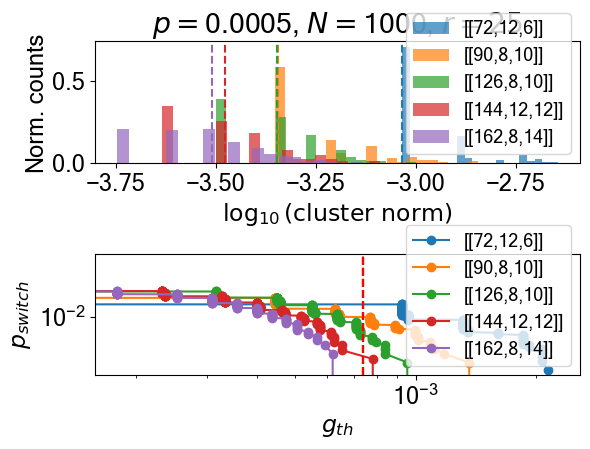

In [2]:
# from realtime_decoding.cluster_norm_distributions import get_cluster_norm_distributions_and_switch_probs, get_cutoff_for_desired_switch_rate
from realtime_decoding.cluster_norm_distributions import process_one_round_value, get_cluster_norm_distributions_and_switch_probs, get_cutoff_for_desired_switch_rate, plot_cluster_norm_distributions_and_switch_probs
from realtime_decoding.decoder_switching_class import *
import numpy as np
from joblib import Parallel, delayed

def main():
    weak_decoder      = 'uf' #basis determining the memory experiment for the BB codes
    code_names = ["[[72,12,6]]", "[[90,8,10]]" ,"[[126,8,10]]", "[[144,12,12]]", "[[162,8,14]]"]   
    # code_names = ["[[72,12,6]]"]
    p = 5e-4
    switch_rate = 1e-4
    num_rounds=25
    num_shots=1_000
    plot_cluster_norm_distributions_and_switch_probs(code_names, p, num_rounds, num_shots, switch_rate, weak_decoder=weak_decoder)
    # cluster_norms, ler_results, yerr_results =  get_cluster_norm_distributions_and_switch_probs(code_names=code_names, p=p)
    # min_cutoff = get_cutoff_for_desired_switch_rate(switch_rate=switch_rate, p=p, cluster_norms=cluster_norms, code_names=code_names)
    # plot_cluster_norm_distributions_and_switch_probs(code_names=code_names, cluster_norms=cluster_norms, p=p, num_rounds=num_rounds, num_shots=num_shots, cutoff=min_cutoff)
    # print(min_cutoff)

if __name__ == '__main__':
     main()


In [1]:
# scan the cluster size stuff for a variety of p
from realtime_decoding.cluster_norm_distributions import get_cluster_norm_distributions_and_switch_probs, get_cutoff_for_desired_switch_rate
import numpy as np
switch_rate = 0.01 # how often to switch
p_list = np.logspace(-4,-2.5, 5)

cluster_norms, ler_results, yerr_results = get_cluster_norm_distributions_and_switch_probs(weak_decoder='bplsd', num_shots=10, p=1e-4)
cutoff = get_cutoff_for_desired_switch_rate(switch_rate=0.001,cluster_norms=cluster_norms, p=1e-4)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
/Users/ariannameinking/miniforge3/envs/realtime_decoding/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


KeyboardInterrupt: 